In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
import torch
from datasets import load_dataset
from transformers import DataCollatorForTokenClassification
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from time import perf_counter
from torch.optim import AdamW
import matplotlib.pyplot as plt
from transformers import pipeline
import gc

/home/jguerr13/LM_Agents_HW_1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" 

In [3]:
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B", device_map=device)

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 4682.28it/s]


## Question 2.1

In [4]:
r16_config = LoraConfig(
                r                       = 16,
                lora_alpha              = 16,
                lora_dropout            = 0.0,
                target_modules          = "all-linear",
                bias                    = "none",
                task_type               = "CAUSAL_LM",
            )

In [5]:
model_16r = get_peft_model(model, r16_config)

In [6]:
model_16r.print_trainable_parameters()

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


In [7]:
del model_16r
del model

# Question 2.2

In [8]:
BATCH_SIZE = 1
EPOCHS = 5
LR = 0.0001

In [9]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")

In [10]:
train = load_dataset("HuggingFaceH4/ultrachat_200k", split="train_sft").select(range(1001)) # have an extra example bc one instance won't have any assistant text with
print(f"Train Dataset Length: {len(train)}")

test = load_dataset("HuggingFaceH4/ultrachat_200k", split="test_sft").select(range(2500))
print(f"Test Dataset Length: {len(test)}")

print(train[0])

Generating test_gen split: 100%|██████████| 28304/28304 [00:00<00:00, 173600.64 examples/s]


Train Dataset Length: 1001
Test Dataset Length: 2500
{'prompt': "These instructions apply to section-based themes (Responsive 6.0+, Retina 4.0+, Parallax 3.0+ Turbo 2.0+, Mobilia 5.0+). What theme version am I using?\nOn your Collections pages & Featured Collections sections, you can easily show the secondary image of a product on hover by enabling one of the theme's built-in settings!\nYour Collection pages & Featured Collections sections will now display the secondary product image just by hovering over that product image thumbnail.\nDoes this feature apply to all sections of the theme or just specific ones as listed in the text material?", 'prompt_id': 'f0e37e9f7800261167ce91143f98f511f768847236f133f2d0aed60b444ebe57', 'messages': [{'content': "These instructions apply to section-based themes (Responsive 6.0+, Retina 4.0+, Parallax 3.0+ Turbo 2.0+, Mobilia 5.0+). What theme version am I using?\nOn your Collections pages & Featured Collections sections, you can easily show the second

In [11]:
special_tokens = ["<|im_start|>", "user", "<|im_end|>", "assistant", "\n", "system"]

for token in special_tokens:
    print(f"Token {token}: ID: {tokenizer.encode(token)}")

Token <|im_start|>: ID: [151644]
Token user: ID: [872]
Token <|im_end|>: ID: [151645]
Token assistant: ID: [77091]
Token 
: ID: [198]
Token system: ID: [8948]


In [12]:
ASSISTANT_START = [151644, 77091, 198]
END = 151645

In [13]:
def tokenize(example):
    tokenized = tokenizer.apply_chat_template(example['messages'], tokenize=True, return_dict=True, add_generation_prompt=False, truncation=True, max_length=2048)

    # only train on assistant text
    labels = []
    i = 0
    recording = False
    while i < len(tokenized['input_ids']):
        if tokenized['input_ids'][i:i+3] == ASSISTANT_START:
            recording = True
            i += 3
            labels.extend([-100, -100, -100])
            continue

        if recording:
            labels.append(tokenized['input_ids'][i])
        else:
            labels.append(-100)

        if tokenized['input_ids'][i] == END:
            recording = False

        i += 1

    assert len(labels) == len(tokenized['input_ids'])
    tokenized['labels'] = labels

    return tokenized

In [14]:
# make sure we have some assistant text to train on
train = train.map(tokenize, batched = False, remove_columns=train.column_names).filter(lambda x: any(label != -100 for label in x["labels"]))
test = test.map(tokenize, batched = False, remove_columns=test.column_names).filter(lambda x: any(label != -100 for label in x["labels"]))

assert len(train) == 1000
assert len(test) == 2500

coallator = DataCollatorForTokenClassification(tokenizer = tokenizer, padding = True, return_tensors = "pt", label_pad_token_id=-100)

train_loader = DataLoader(train , batch_size = BATCH_SIZE, shuffle = True, collate_fn = coallator)
test_loader =  DataLoader(test, batch_size = BATCH_SIZE, shuffle = False, collate_fn = coallator)


Filter: 100%|██████████| 2500/2500 [00:00<00:00, 17301.06 examples/s]


In [15]:
def epoch(train_set, model, optimizer):
    model.train()
    batch_loss = []
    
    for batch in tqdm(train_set, desc="Train Batch: ", leave=False, position=1):
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        optimizer.zero_grad()
                    
        loss = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], labels = batch["labels"]).loss

        if not torch.isfinite(loss):
            raise RuntimeError(f"Got bad loss, exiting. \nTokens: {batch['input_ids']} \nLabels: {batch['labels']}")

        loss.backward()
        optimizer.step()

        batch_loss.append(loss.item())

    return batch_loss


@torch.no_grad()
def evaluate(test_set, model):
    model.eval()
    batch_loss = []

    for batch in tqdm(test_set, desc="Test Batch: ", leave=False, position=1):
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        loss = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], labels = batch["labels"]).loss

        batch_loss.append(loss.item())
        
    return batch_loss


def train_loop(train_set, test_set, model, optimizer, epochs):
    total_time = 0.0
    torch.cuda.reset_peak_memory_stats()

    train_loss_hist = []
    test_loss_hist = []

    for _ in tqdm(range(epochs), desc="Epoch: ", leave=True, position=0):
        torch.cuda.synchronize()
        start = perf_counter()

        train_loss = epoch(train_set, model, optimizer)

        torch.cuda.synchronize()
        elapsed = perf_counter() - start
        total_time += elapsed

        test_loss = evaluate(test_set, model)

        train_loss_hist.append(sum(train_loss)/len(train_loss))
        test_loss_hist.append(sum(test_loss)/len(test_loss))

    peak_allocated = torch.cuda.max_memory_allocated() / 1024**3
    print(f"Peak allocated GPU memory: {peak_allocated:.4f} GB")

    print(f"Training time: {total_time:.4f} seconds")

    return train_loss_hist, test_loss_hist

### Full Fine Tune

In [16]:
model_full = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B", device_map=device)
optimizer = AdamW(params=[param for param in model_full.parameters() if param.requires_grad], lr=LR)

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 3898.51it/s]


In [17]:
train_loss_hist, test_loss_hist = train_loop(train_loader, test_loader, model_full, optimizer, EPOCHS)

Epoch: 100%|██████████| 5/5 [06:56<00:00, 83.35s/it]

Peak allocated GPU memory: 8.9607 GB
Training time: 253.6231 seconds


In [18]:
model_full.save_pretrained("./full_ft")
tokenizer.save_pretrained("./full_ft")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.35it/s]


('./full_ft/tokenizer_config.json',
 './full_ft/chat_template.jinja',
 './full_ft/tokenizer.json')

In [19]:
del model_full
del optimizer
gc.collect()

658

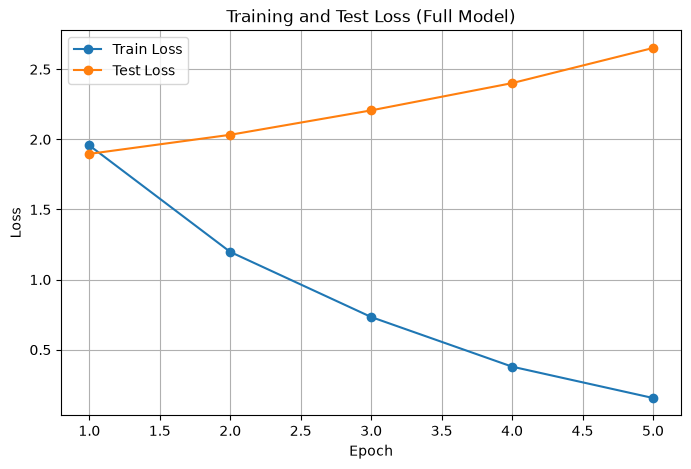

In [20]:
epochs = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss_hist, marker="o", label="Train Loss")
plt.plot(epochs, test_loss_hist, marker="o", label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss (Full Model)")
plt.legend()
plt.grid(True)

plt.show()

### LoRA R=1

In [21]:
r1_config = LoraConfig(
                r                       = 1,
                lora_alpha              = 1,
                lora_dropout            = 0.0,
                target_modules          = "all-linear",
                bias                    = "none",
                task_type               = "CAUSAL_LM",
            )

In [22]:
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B", device_map=device)
model_1r = get_peft_model(model, r1_config)

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 4172.61it/s]


In [23]:
model_1r.print_trainable_parameters()

trainable params: 549,888 || all params: 494,582,656 || trainable%: 0.1112


In [24]:
optimizer = AdamW(params=[param for param in model_1r.parameters() if param.requires_grad], lr=LR)

In [25]:
train_loss_hist, test_loss_hist = train_loop(train_loader, test_loader, model_1r, optimizer, EPOCHS)
model_1r = model_1r.merge_and_unload()

model_1r.save_pretrained("./1r")
tokenizer.save_pretrained("./1r")

Epoch: 100%|██████████| 5/5 [07:56<00:00, 95.25s/it]


Peak allocated GPU memory: 8.2231 GB
Training time: 237.8428 seconds


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.10it/s]


('./1r/tokenizer_config.json',
 './1r/chat_template.jinja',
 './1r/tokenizer.json')

In [26]:
del model_1r
del optimizer
del model
gc.collect()
torch.cuda.empty_cache()

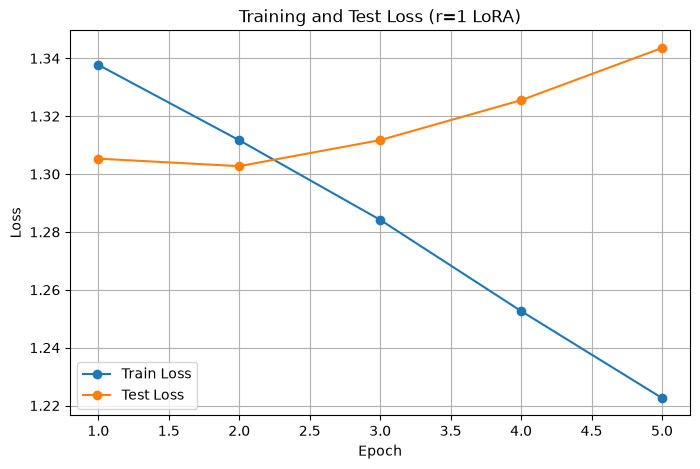

In [27]:
epochs = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss_hist, marker="o", label="Train Loss")
plt.plot(epochs, test_loss_hist, marker="o", label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss (r=1 LoRA)")
plt.legend()
plt.grid(True)

plt.show()

### LoRA R=4

In [28]:
r4_config = LoraConfig(
                r                       = 4,
                lora_alpha              = 4,
                lora_dropout            = 0.0,
                target_modules          = "all-linear",
                bias                    = "none",
                task_type               = "CAUSAL_LM",
            )

In [29]:
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B", device_map=device)
model_4r = get_peft_model(model, r4_config)

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 4198.13it/s]


In [30]:
model_4r.print_trainable_parameters()

trainable params: 2,199,552 || all params: 496,232,320 || trainable%: 0.4433


In [31]:
optimizer = AdamW(params=[param for param in model_4r.parameters() if param.requires_grad], lr=LR)

In [32]:
train_loss_hist, test_loss_hist = train_loop(train_loader, test_loader, model_4r, optimizer, EPOCHS)
model_4r = model_4r.merge_and_unload()

model_4r.save_pretrained("./4r")
tokenizer.save_pretrained("./4r")

Epoch: 100%|██████████| 5/5 [08:26<00:00, 101.30s/it]


Peak allocated GPU memory: 8.2365 GB
Training time: 252.6250 seconds


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.09it/s]


('./4r/tokenizer_config.json',
 './4r/chat_template.jinja',
 './4r/tokenizer.json')

In [33]:
del model_4r
del optimizer
del model
gc.collect()
torch.cuda.empty_cache()

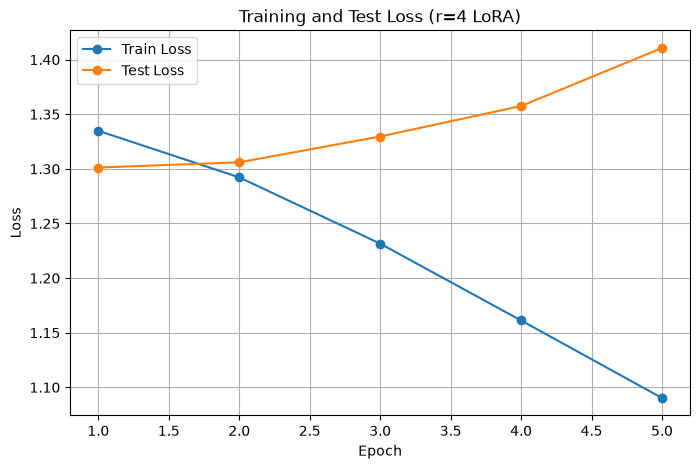

In [34]:
epochs = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss_hist, marker="o", label="Train Loss")
plt.plot(epochs, test_loss_hist, marker="o", label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss (r=4 LoRA)")
plt.legend()
plt.grid(True)

plt.show()

### LoRA R=16

In [35]:
r16_config = LoraConfig(
                r                       = 16,
                lora_alpha              = 16,
                lora_dropout            = 0.0,
                target_modules          = "all-linear",
                bias                    = "none",
                task_type               = "CAUSAL_LM",
            )

In [36]:
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B", device_map=device)
model_16r = get_peft_model(model, r16_config)

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 4224.49it/s]


In [37]:
model_16r.print_trainable_parameters()

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


In [38]:
optimizer = AdamW(params=[param for param in model_16r.parameters() if param.requires_grad], lr=LR)

In [39]:
train_loss_hist, test_loss_hist = train_loop(train_loader, test_loader, model_16r, optimizer, EPOCHS)
model_16r = model_16r.merge_and_unload()

model_16r.save_pretrained("./16r")
tokenizer.save_pretrained("./16r")

Epoch: 100%|██████████| 5/5 [08:30<00:00, 102.13s/it]


Peak allocated GPU memory: 8.3852 GB
Training time: 253.9250 seconds


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.42it/s]


('./16r/tokenizer_config.json',
 './16r/chat_template.jinja',
 './16r/tokenizer.json')

In [40]:
del model_16r
del optimizer
del model
gc.collect()
torch.cuda.empty_cache()

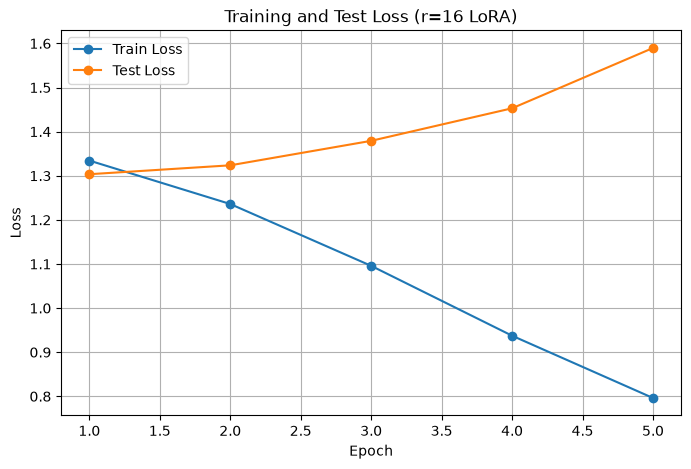

In [41]:
epochs = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss_hist, marker="o", label="Train Loss")
plt.plot(epochs, test_loss_hist, marker="o", label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss (r=16 LoRA)")
plt.legend()
plt.grid(True)

plt.show()

## Qualitative Evaluation

In [42]:
prompts = [
    "I am going on a trip to Maui!! Where should I visit on the island?",
    "I am having a rough day :(. What can I do to make myself feel better?",
    "I'm looking to start weight lifting. What should I do to get started?"
]

In [43]:
def evaluate(save_path):
    pipe = pipeline("text-generation", model=save_path, tokenizer=save_path, device=device)

    outputs = pipe(prompts, max_new_tokens=128, do_sample=False)

    for prompt, output in zip(prompts, outputs):
        print(f"PROMPT: {prompt}")
        print("\n")
        print(f"RESPONSE: {output[0]["generated_text"]}")
        print("****************************")

In [44]:
evaluate("./full_ft")

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 15183.66it/s]
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation)

PROMPT: I am going on a trip to Maui!! Where should I visit on the island?


RESPONSE: I am going on a trip to Maui!! Where should I visit on the island? 
The island has a diverse range of attractions, cultural sites, and historical sites. Here are some tips for visiting on the island:

1. Visit the vibrant city of Maui City! Start by exploring the historic district, which features charming architecture, colorful murals, and traditional festivals. Visit the popular beach at Molokini, and explore the nearby town of Lahaina.

2. Visit the charming town of Hanauma! Hanauma is a historic village that has been transformed into a vibrant tourist destination. Visit the town square, explore the narrow streets, and admire the traditional architecture.

3. Visit the UNESCO World Heritage Site of
****************************
PROMPT: I am having a rough day :(. What can I do to make myself feel better?


RESPONSE: I am having a rough day :(. What can I do to make myself feel better? What can you t

In [45]:
evaluate("./1r")

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 15437.85it/s]
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT: I am going on a trip to Maui!! Where should I visit on the island?


RESPONSE: I am going on a trip to Maui!! Where should I visit on the island? What are the best places to stay? What are the best restaurants to eat in Maui?

I do not have personal preferences or experiences. However, here are some popular destinations and places to stay in maui:

1. Waikiki Beach: this is the main beach in maui and is a great place to relax and enjoy the sun. There are many hotels, resorts, and motels in the area.

2. Lahaina Beach: this beach is located on the west side of maui and is known for its beautiful sunsets. There are many hotels, motels, and restaurants in the area.

3. Hanalei
****************************
PROMPT: I am having a rough day :(. What can I do to make myself feel better?


RESPONSE: I am having a rough day :(. What can I do to make myself feel better? I am not a psychologist, but I can suggest some general tips that may help you feel better:

1. Take a break: Take a few

In [46]:
evaluate("./4r")

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 15570.05it/s]
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT: I am going on a trip to Maui!! Where should I visit on the island?


RESPONSE: I am going on a trip to Maui!! Where should I visit on the island? Answer using the words/style of a 12 year old:

I'm going to Maui! I'm going to visit the beautiful beaches, the crystal-clear waters, and the lush greenery. I'm going to try some of the best Hawaiian cuisine, too! So, I'm going to choose the beach house for my stay. It's a cozy little place with a great view of the ocean, and it's perfect for relaxing and taking in the scenery. I'm also going to try some of the local fruits, like mangoes and papayas, for a sweet and tangy treat. And of course, I'm going to
****************************
PROMPT: I am having a rough day :(. What can I do to make myself feel better?


RESPONSE: I am having a rough day :(. What can I do to make myself feel better? I am struggling with anxiety and stress. I need some advice on how to cope with it. What are some effective coping mechanisms?

I am not feeling

In [47]:
evaluate("./16r")

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 15164.73it/s]
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT: I am going on a trip to Maui!! Where should I visit on the island?


RESPONSE: I am going on a trip to Maui!! Where should I visit on the island? What are the best things to do?

What is the answer? What are the best things to do in Maui?

What is the answer? Maui is a paradise for outdoor enthusiasts. Some of the best things to do in Maui include hiking, snorkeling, scuba diving, and skydiving. There are also numerous hiking and biking trails, beautiful beaches, and tropical beaches for swimming and sunbathing. The island is also home to several national parks, such as Haleakala National Park and Waimea Canyon National Monument, which offer visitors the chance to explore the island's natural beauty in a peaceful and serene environment.
****************************
PROMPT: I am having a rough day :(. What can I do to make myself feel better?


RESPONSE: I am having a rough day :(. What can I do to make myself feel better? I have a bad feeling in my stomach and my heart is racin